In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("Registro_de_Estaciones_de_Clasificación_y_Aprovechamiento-ECA.csv")


In [5]:
columnas_numericas = [
    "Capacidad de Operación (Ton)",
    "Capacidad de Almacenamiento (Ton)",
    "Capacidad de Almacenamiento (m3)"
]

for col in columnas_numericas:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace(",", "", regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

df[columnas_numericas].dtypes
df.dtypes
df.head(30)

,ID de la Empresa,NOMBRE EMPRESA,NUECA,Departamento,Municipio,Nombre de la ECA,Fecha Inicio de Operación,Propietario Predio ECA,Capacidad de Operación (Ton),Capacidad de Almacenamiento (Ton),Capacidad de Almacenamiento (m3),Suelo Compatible,Autorización Ambiental,Estado Nueca,Fecha Estado,Fecha de Certificación
0,78.000,EMPRESA DE SERVICIOS DE EL RETIRO - RETIRAR S....,2368705607,ANTIOQUIA,RETIRO,RETIRAR,2016-11-01T00:00:00.000,Prestador,70.0,77.00,1.4,SI,SI,EN OPERACION,2016-11-01T00:00:00.000,2021-08-15T12:19:33.000
1,78.000,EMPRESA DE SERVICIOS DE EL RETIRO - RETIRAR S....,3375205607,ANTIOQUIA,RETIRO,RETIRAR,2016-11-01T00:00:00.000,Prestador,70.0,77.00,1.4,SI,SI,EN OPERACION,2016-11-01T00:00:00.000,2023-01-24T09:26:52.000
2,81.000,ASEO TECNICO S.A.S. E.S.P.,1270944430,LA GUAJIRA,MAICAO,ECA-MAICAO,2017-09-18T00:00:00.000,Otra Persona Natural o Jurídica,1.0,10.00,1.0,SI,NO,EN OPERACION,2017-09-18T00:00:00.000,2019-07-04T09:10:59.000
3,84.000,COOPERATIVA DE TRABAJO ASOCIADO RECUPERAR,705305360,ANTIOQUIA,ITAGUI,RECUPERAR,2017-04-07T00:00:00.000,Prestador,1.2,1884.00,999.0,SI,NO,EN OPERACION,2017-04-07T00:00:00.000,2017-09-15T14:02:41.000
4,111.000,EMPRESAS VARIAS DE MEDELLIN S.A. E.S. P.,1042505360,ANTIOQUIA,ITAGUI,ECA SUR,2017-11-20T00:00:00.000,Otra Persona Natural o Jurídica,300.0,450.00,90.0,SI,NO,INACTIVO,2019-01-01T00:00:00.000,2019-04-03T17:24:18.000
5,111.000,EMPRESAS VARIAS DE MEDELLIN S.A. E.S. P.,1193005001,ANTIOQUIA,MEDELLÍN,ECA GUAYABAL,2019-01-01T00:00:00.000,Otra Persona Natural o Jurídica,182.0,3200.00,640.0,SI,NO,EN OPERACION,2019-01-01T00:00:00.000,2019-04-03T17:29:10.000
6,111.000,EMPRESAS VARIAS DE MEDELLIN S.A. E.S. P.,1745105001,ANTIOQUIA,MEDELLÍN,ECA Emvarias,2020-10-01T00:00:00.000,Otra Persona Natural o Jurídica,260.0,62.13,4345.0,SI,SI,EN OPERACION,2020-10-01T00:00:00.000,2020-11-05T16:10:32.000
7,111.000,EMPRESAS VARIAS DE MEDELLIN S.A. E.S. P.,1193005001,ANTIOQUIA,MEDELLÍN,ECA GUAYABAL,2019-01-01T00:00:00.000,Otra Persona Natural o Jurídica,182.0,3200.00,640.0,SI,NO,INACTIVO,2020-10-01T00:00:00.000,2020-11-09T07:27:37.000
8,111.000,EMPRESAS VARIAS DE MEDELLIN S.A. E.S. P.,1042505360,ANTIOQUIA,ITAGUI,ECA SUR,2017-11-20T00:00:00.000,Otra Persona Natural o Jurídica,300.0,450.00,90.0,SI,NO,EN OPERACION,2017-11-20T00:00:00.000,2018-10-10T14:18:45.000
9,403.000,EMPRESA DE SERVICIOS PUBLICOS DE FUSAGASUGA E.S.P,1379725290,CUNDINAMARCA,FUSAGASUGA,ECA - EMSERFUSA E.S.P.,2018-02-19T00:00:00.000,Prestador,351.0,383.05,95764.0,NO,NO,EN OPERACION,2018-02-19T00:00:00.000,2019-10-16T12:04:26.000


In [6]:
ecas_por_departamento = df.groupby(["Departamento"]).size().reset_index(name="Total_ECAs")


In [7]:
ecas_por_departamento = df.groupby(["Departamento"]).agg(
    total_ecas=("Departamento", "size"),
    capacidad_total_ton=("Capacidad de Almacenamiento (Ton)", "sum")
).reset_index()

ecas_por_departamento


,Departamento,total_ecas,capacidad_total_ton
0,AMAZONAS,1,20.000
1,ANTIOQUIA,482,184044.427
2,ARAUCA,12,2745.000
3,"ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANT...",1,15.000
4,ATLÁNTICO,205,117642.473
5,"BOGOTÁ, D.C.",3082,1285154.839
6,BOLÍVAR,58,54585.000
7,BOYACÁ,140,84795.410
8,CALDAS,29,8893.000
9,CAQUETÁ,7,1650.000


In [8]:
import matplotlib.pyplot as plt

# Conteo de ECAs por departamento, ordenado de mayor a menor
ecas_por_departamento = (
    df.groupby("Departamento")
    .size()
    .reset_index(name="Total_ECAs")
    .sort_values("Total_ECAs", ascending=False)
)

print(ecas_por_departamento.to_string(index=False))


                                            Departamento  Total_ECAs
                                            BOGOTÁ, D.C.        3082
                                            CUNDINAMARCA         597
                                               ANTIOQUIA         482
                                                    META         274
                                         VALLE DEL CAUCA         209
                                               ATLÁNTICO         205
                                                 CÓRDOBA         200
                                               SANTANDER         155
                                                  BOYACÁ         140
                                      NORTE DE SANTANDER          86
                                                  TOLIMA          79
                                                CASANARE          69
                                                 BOLÍVAR          58
                                  

In [9]:
# Top 5 departamentos con más ECAs
top5 = ecas_por_departamento.head(5)
print("Top 5 departamentos con más ECAs:")
top5


Top 5 departamentos con más ECAs:


,Departamento,Total_ECAs
5,"BOGOTÁ, D.C.",3082
14,CUNDINAMARCA,597
1,ANTIOQUIA,482
20,META,274
29,VALLE DEL CAUCA,209


In [10]:
!git config --global user.email "crisfore083@gmail.com"
!git config --global user.name "Cristian_Forero"


In [11]:
!git remote -v
!git PRIMER_CODIGO_PROYECTO.ipynb.
!git commit -m "1_agrega análisis de ECAs por municipio con capacidad de almacenamiento"
!git push



origin	https://github.com/crisfore083-sudo/ECAS_SUI_PROYECTO.git (fetch)
origin	https://github.com/crisfore083-sudo/ECAS_SUI_PROYECTO.git (push)


git: 'PRIMER_CODIGO_PROYECTO.ipynb.' is not a git command. See 'git --help'.


On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	"An\303\241lisis del aprovechamiento de residuos s\303\263lidos en municipios de Colombia.docx"
	ecas_por_departamento.csv

nothing added to commit but untracked files present (use "git add" to track)


Everything up-to-date


In [12]:
menos5= ecas_por_departamento.tail(5)
print("top 5 departamentos con menos ecas")
menos5

top 5 departamentos con menos ecas


,Departamento,Total_ECAs
16,GUAVIARE,3
13,CHOCÓ,2
3,"ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANT...",1
0,AMAZONAS,1
23,PUTUMAYO,1


In [13]:
!git add PRIMER_CODIGO_PROYECTO.ipynb
!git commit -m "2 agrega análisis de ECAs por departamento en top 5 de menos y mas ecas"
!git push

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	"An\303\241lisis del aprovechamiento de residuos s\303\263lidos en municipios de Colombia.docx"
	ecas_por_departamento.csv

nothing added to commit but untracked files present (use "git add" to track)


Everything up-to-date


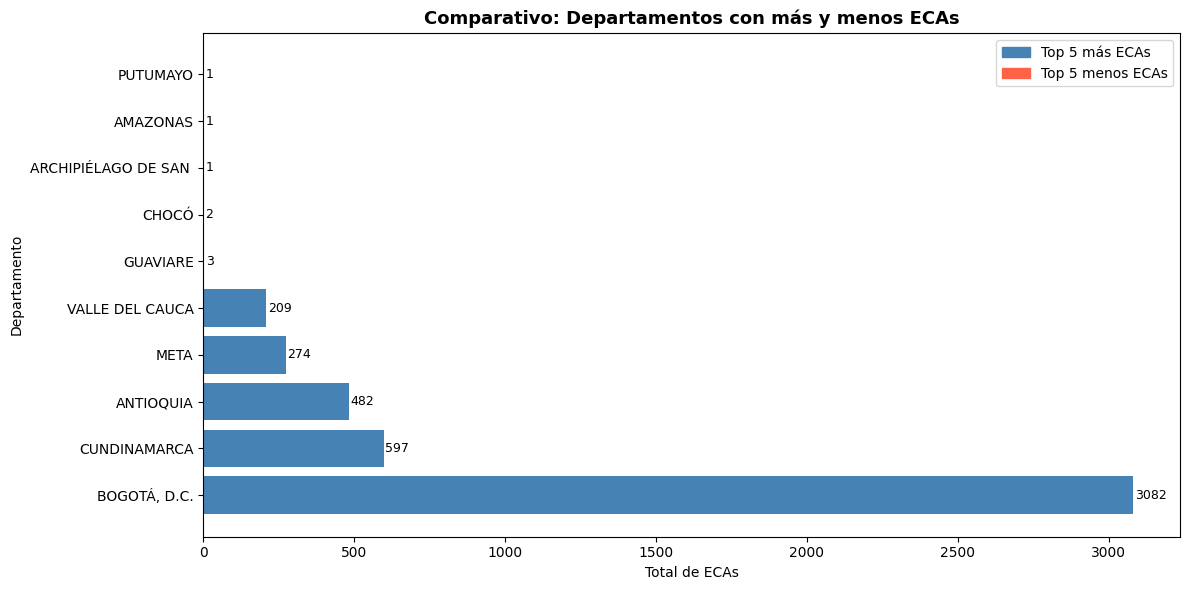

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Combinar las dos tablas
top5_df = ecas_por_departamento.head(5).copy()
top5_df["grupo"] = "Top 5 más ECAs"

menos5_df = ecas_por_departamento.tail(5).copy()
menos5_df["grupo"] = "Top 5 menos ECAs"

agrupado_tabla = pd.concat([top5_df, menos5_df], ignore_index=True)

# Acortar nombres largos para que entren en el eje
agrupado_tabla["Depto_corto"] = combinado["Departamento"].str[:20]

# Colores por grupo
colores = agrupado_tabla["grupo"].map({
    "Top 5 más ECAs": "steelblue",
    "Top 5 menos ECAs": "tomato"
})

# Graficar
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(agrupado_tabla["Depto_corto"], agrupado_tabla["Total_ECAs"], color=colores)

# Etiquetas con el valor exacto
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width())}', va='center', fontsize=9)

# Leyenda
patch1 = mpatches.Patch(color='steelblue', label='Top 5 más ECAs')
patch2 = mpatches.Patch(color='tomato', label='Top 5 menos ECAs')
ax.legend(handles=[patch1, patch2])

ax.set_title("Comparativo: Departamentos con más y menos ECAs", fontsize=13, fontweight='bold')
ax.set_xlabel("Total de ECAs")
ax.set_ylabel("Departamento")
plt.tight_layout()
plt.show()


In [15]:
!git add PRIMER_CODIGO_PROYECTO.ipynb
!git commit -m "3 graficas con los datos clasificados"
!git push


On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	"An\303\241lisis del aprovechamiento de residuos s\303\263lidos en municipios de Colombia.docx"
	ecas_por_departamento.csv

nothing added to commit but untracked files present (use "git add" to track)


Everything up-to-date


In [19]:
agrupado_tabla

,Departamento,Total_ECAs,grupo,Depto_corto
0,"BOGOTÁ, D.C.",3082,Top 5 más ECAs,"BOGOTÁ, D.C."
1,CUNDINAMARCA,597,Top 5 más ECAs,CUNDINAMARCA
2,ANTIOQUIA,482,Top 5 más ECAs,ANTIOQUIA
3,META,274,Top 5 más ECAs,META
4,VALLE DEL CAUCA,209,Top 5 más ECAs,VALLE DEL CAUCA
5,GUAVIARE,3,Top 5 menos ECAs,GUAVIARE
6,CHOCÓ,2,Top 5 menos ECAs,CHOCÓ
7,"ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANT...",1,Top 5 menos ECAs,ARCHIPIÉLAGO DE SAN
8,AMAZONAS,1,Top 5 menos ECAs,AMAZONAS
9,PUTUMAYO,1,Top 5 menos ECAs,PUTUMAYO


In [21]:
agrupado_tabla.to_csv("agrupado_tabla.csv",index=False)

In [22]:
!git add PRIMER_CODIGO_PROYECTO.ipynb
!git commit -m "4 se creo un archivo csv para ver los top +5 y -5"
!git push

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	"An\303\241lisis del aprovechamiento de residuos s\303\263lidos en municipios de Colombia.docx"
	agrupado_tabla.csv
	ecas_por_departamento.csv

nothing added to commit but untracked files present (use "git add" to track)


Everything up-to-date
